# 00 · Your first EEG in MNE

**ROBT613 · Brain–Computer Interfaces** | Teaching session + independent lab

## Goal
Inspect sampling, voltage units, channel names and event markers; understand the Raw → Epochs → Evoked workflow before starting the P300 track.

**Data:** No external recording

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## How to study this notebook

This is both the classroom lesson and the independent-study workbook. Everything needed for the exercises—questions, hints, executable solutions, checks and explanations—is here. Work from top to bottom in a fresh runtime.

1. Read the question and calculate a small example on paper.
2. Write your prediction before running the next code cell.
3. Try the practice task in its workspace.
4. Continue to the worked solution and compare the reasoning, not just the number.
5. Change one parameter and explain what the result means.

**For a live class:** pause at each “Try it” heading. The solution follows in the same notebook, so no separate answer document is required. Saved figures support reading without execution; downloading real data and rerunning cells requires internet on the first run. Code comments explain each analysis statement, and longer loops are explained before execution.

**Prerequisites:** basic Python arrays, arithmetic and plotting. The symbol guide below defines the mathematical notation used here. These lessons stay at the sensor level; EEG source imaging is outside the course.

## The question for today

You have received a recording with 64 EEG channels and event markers. Before analyzing any brain response, a collaborator asks three simple questions: what does one number mean, what does one axis mean, and where does an event fall in that array? Today we build the answers from a tiny signal whose properties we know.

### By the end you should be able to

- Translate among samples, seconds, volts and microvolts without changing the measurement.
- Read array shapes aloud and identify which axis an operation reduces.
- Explain the responsibilities of Raw, Info, Annotations, Epochs and Evoked.
- Use a copy when an MNE method changes an object in place.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The first worked examples use controlled arrays; the later walkthrough and applied practice use the dataset stated above. Practice workspaces, hints and worked solutions are placed beside the relevant methods. Complete your attempt before continuing to the reference solution.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


## Visual route through the lesson

Follow the arrows before running the analysis. For each box, say what the input represents, what changes, and what must be preserved.

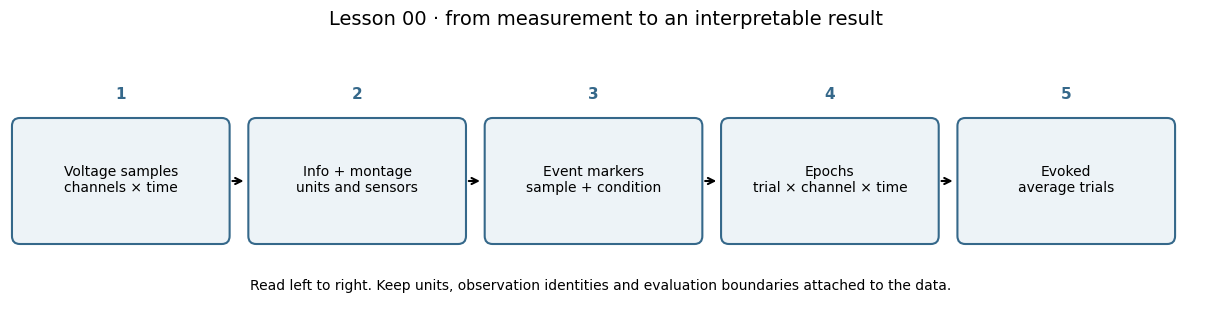

In [2]:
# Drawing code for the lesson map; no analysis data are transformed here.
from matplotlib.patches import FancyBboxPatch
map_steps=['Voltage samples\nchannels × time', 'Info + montage\nunits and sensors', 'Event markers\nsample + condition', 'Epochs\ntrial × channel × time', 'Evoked\naverage trials']
fig,map_ax=plt.subplots(figsize=(12,3.1),constrained_layout=True)
map_ax.set(xlim=(-.1,12),ylim=(-.3,2.4));map_ax.axis('off')
for map_i,map_label in enumerate(map_steps):
    map_x=map_i*2.4
    map_ax.add_patch(FancyBboxPatch((map_x,.45),2.05,1.1,
        boxstyle='round,pad=0.08',facecolor='#edf3f7',edgecolor='#35688a',linewidth=1.5))
    map_ax.text(map_x+1.025,1.02,map_label,ha='center',va='center',fontsize=10)
    map_ax.text(map_x+1.025,1.83,str(map_i+1),ha='center',weight='bold',color='#35688a')
    if map_i<4:map_ax.annotate('',xy=(map_x+2.3,1),xytext=(map_x+2.13,1),arrowprops=dict(arrowstyle='->',lw=1.5))
map_ax.text(5.9,-.08,'Read left to right. Keep units, observation identities and evaluation boundaries attached to the data.',ha='center',fontsize=10)
map_ax.set_title('Lesson 00 · from measurement to an interpretable result',fontsize=14,pad=12)
plt.show()

**Read the map:** the arrows represent processing order, not permission to fit on all observations. When a stage learns parameters, keep evaluation data outside that fit. The map is also available as text: Voltage samples: channels × time → Info + montage: units and sensors → Event markers: sample + condition → Epochs: trial × channel × time → Evoked: average trials.

## Symbols and a calculation by hand

$f_s$: samples/s; $n$: zero-based sample index; $x$: voltage in V; $C$: channels; $T$: samples.

### Derive the operation before calling the library

A discrete sample has time $t_n=n/f_s$. Solve for its index: $n=\operatorname{round}(tf_s)$. At 128 Hz, $t=0.5$ s gives $n=64$. A two-second acquisition contains $2\times128=256$ samples indexed 0 through 255; its last timestamp is $255/128=1.9921875$ s.

To display volts as microvolts, multiply by $10^6$: $20\times10^{-6}\,V=20\,\mu V$. Unit conversion changes numerical scale; resampling changes the time grid; changing `sfreq` metadata alone reinterprets the existing samples. These are three distinct operations.

### Your paper calculation

Rewrite one equation with the numerical example above. Name the input units and output units, and identify the axis being reduced or transformed.

**My calculation:** _write your intermediate steps here before continuing._

### A map of the analysis objects

Think of `Raw` as a labeled multichannel recording, not simply an array. `raw.get_data()` supplies the numerical samples, but `raw.info` tells you how to interpret them. Losing the sampling frequency is like removing the scale from a ruler. Losing channel types can cause an eye-movement sensor to be included in an EEG average. Losing event timing makes a perfectly implemented classifier answer the wrong question.

| Object | Numerical organization | Question it answers |
|---|---|---|
| `Raw` | channel × sample | What was recorded continuously? |
| `Info` | metadata | At what rate, with which sensors and units? |
| `Annotations` | onset, duration, description | What happened over an interval? |
| Events array | sample, previous value, code | Where are discrete event onsets? |
| `Epochs` | trial × channel × time | What happened around each event? |
| `Evoked` | channel × time | What is the average event-locked response? |

A NumPy reduction is an explicit scientific choice. `X.mean(axis=0)` on epochs averages trials and retains channel and time. `X.mean(axis=-1)` averages time and retains trial and channel. Both expressions are valid Python; only one answers a particular question. This is why we inspect shapes after transformations rather than waiting for a plotting error.

### Derive the time axis instead of memorizing it

A sample rate of 128 Hz means 128 sample intervals per second. The first sample is at time zero; the last of 128 samples is at $127/128$ s, not 1 s. An inclusive epoch from −0.2 to 0.6 s may have a sample count that surprises you because the requested times are rounded to the sample grid and both endpoints may be included. Use `epochs.times`, rather than constructing a second approximate time axis.

We use synthetic signals in this orientation because they let us know the correct answer in advance. Later recordings will not have a known clean waveform. A successful unit check establishes that the software is behaving consistently, not that a real experimental signal is meaningful.

## Visual intuition · See the three array axes

**Try it:** Locate one trial, one channel and one time point. Which axis disappears when we calculate an ERP?

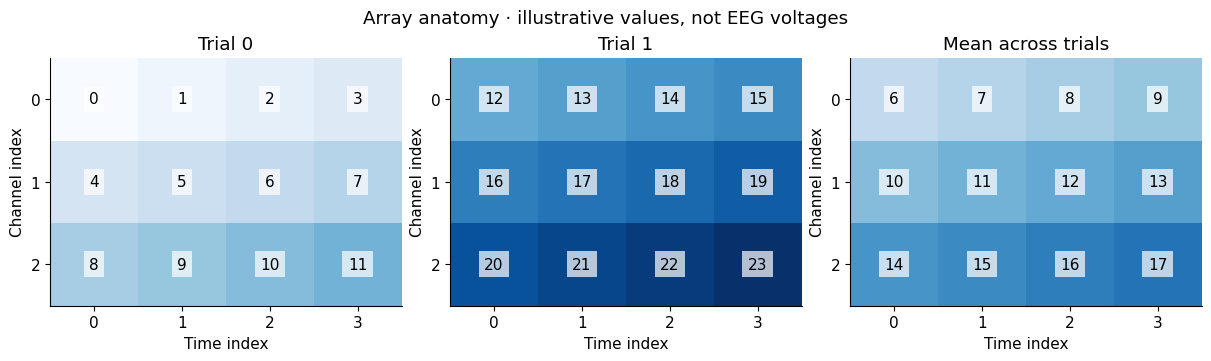

In [3]:
vis_values=np.arange(24).reshape(2,3,4)
fig,axes=plt.subplots(1,3,figsize=(12,3.5),constrained_layout=True)
for ax,values,title in zip(axes,[vis_values[0],vis_values[1],vis_values.mean(0)],['Trial 0','Trial 1','Mean across trials']):
    ax.imshow(values,cmap='Blues',vmin=0,vmax=23,aspect='auto')
    for row in range(3):
        for col in range(4):ax.text(col,row,f'{values[row,col]:g}',ha='center',va='center',color='black',bbox=dict(facecolor='white',alpha=.7,edgecolor='none'))
    ax.set(xticks=range(4),yticks=range(3),xlabel='Time index',ylabel='Channel index',title=title)
fig.suptitle('Array anatomy · illustrative values, not EEG voltages')
plt.show()

### Worked interpretation

The average preserves three channels and four times. At channel 0/time 0, the two trial values 0 and 12 become 6. Averaging the last axis would instead produce one mean per trial and channel.

## Guided practice 1 · sample arithmetic

Predict before running: how many samples are in 2 seconds at 128 Hz? What time is sample 64? Calculate both on paper. We explicitly separate a **duration** from the timestamp of the last sample.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [4]:
demo_fs=128
sample_count=int(2*demo_fs)
sample_times=np.arange(sample_count)/demo_fs
print('Sample count:',sample_count)
print('Time of sample 64:',sample_times[64])
print('Last sample:',sample_times[-1], 'duration:',sample_count/demo_fs)
assert sample_count==256 and sample_times[64]==.5

Sample count: 256
Time of sample 64: 0.5
Last sample: 1.9921875 duration: 2.0


### Why this result makes sense

The recording spans 256 sampling intervals, while the final stored timestamp is one interval short of 2 s. This distinction matters when converting event indices or choosing a window endpoint.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 2 · axes are part of the method

We make a tiny array with two trials, three channels and four times. Trace the first trial by hand. Do not use EEG-sized arrays until you can explain these smaller reductions.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [5]:
toy_epochs=np.arange(24,dtype=float).reshape(2,3,4)
print('Trial 0:\n',toy_epochs[0])
print('Average over trials:\n',toy_epochs.mean(axis=0))
print('Average over time:\n',toy_epochs.mean(axis=-1))
print('Shapes:',toy_epochs.shape,toy_epochs.mean(0).shape,toy_epochs.mean(-1).shape)

Trial 0:
 [[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]]
Average over trials:
 [[ 6.  7.  8.  9.]
 [10. 11. 12. 13.]
 [14. 15. 16. 17.]]
Average over time:
 [[ 1.5  5.5  9.5]
 [13.5 17.5 21.5]]
Shapes: (2, 3, 4) (3, 4) (2, 3)


### Why this result makes sense

Trial averaging produces a 3×4 waveform; time averaging produces two sets of three channel features. An array with the right number of elements can still have the wrong axis meaning.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 3 · prove the unit conversion

A 20 µV sample is stored as $20\times10^{-6}$ V. Perform the conversion once at import or presentation, not repeatedly at every processing step. Dimensional analysis is a useful debugging tool.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [6]:
voltage_uV=np.array([-20.,0.,20.])
voltage_V=voltage_uV*1e-6
print('Stored volts:',voltage_V)
print('Displayed microvolts:',voltage_V*1e6)
assert np.allclose(voltage_V*1e6,voltage_uV)

Stored volts: [-2.e-05  0.e+00  2.e-05]
Displayed microvolts: [-20.   0.  20.]


### Why this result makes sense

A factor-of-one-million mistake can make every epoch appear artifactual. Inspect magnitude as well as shape.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 4 · what averaging can and cannot remove

For independent noise $\epsilon_i$ with variance $\sigma^2$, the average has variance $\sigma^2/N$. Now compare independent trial noise with an artifact copied identically into every trial. The shared component survives averaging.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

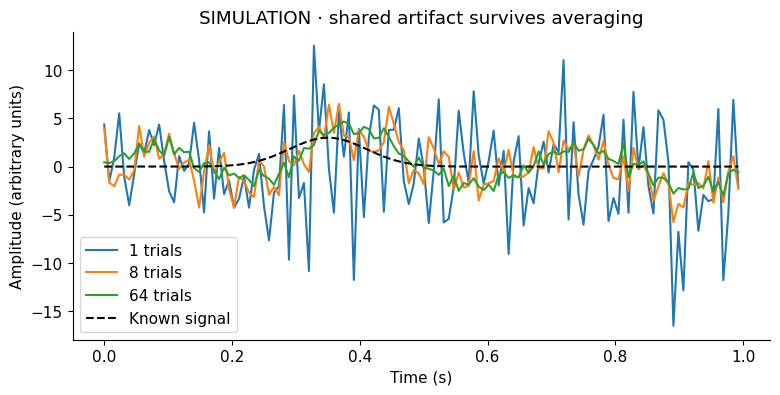

In [7]:
demo_t=np.linspace(0,1,128,endpoint=False)
demo_signal=3*np.exp(-.5*((demo_t-.35)/.06)**2)
demo_trials=demo_signal+rng.normal(0,5,(128,128))
shared_artifact=2*np.sin(2*np.pi*3*demo_t)
fig,ax=plt.subplots()
for count in [1,8,64]:
    ax.plot(demo_t,demo_trials[:count].mean(0)+shared_artifact,label=f'{count} trials')
ax.plot(demo_t,demo_signal,'k--',label='Known signal')
ax.set(xlabel='Time (s)',ylabel='Amplitude (arbitrary units)',title='SIMULATION · shared artifact survives averaging')
ax.legend();plt.show()

### Why this result makes sense

Look for reduced random fluctuation as the trial count increases, but persistent deviation from the known signal. More data does not automatically cure systematic measurement error.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Practice 1 · Unit conversion

Implement `to_volts` below and test positive, negative and zero values. Explain why the plotting label alone cannot repair incorrectly stored units.

**Try it:** complete the function below before reading its solution. The template deliberately returns None so that an unfinished attempt does not interrupt the rest of the lesson.

In [8]:
def to_volts(values_uV):
    # TODO: convert a NumPy-compatible input from microvolts to volts.
    return None

### Hint

Use the equation above and keep the trial/channel axes intact unless the requested output removes them. Test the smallest example by hand first.

### Worked solution

Compare this implementation with your attempt. The next cell checks the reference answer on a concrete numerical case.

In [9]:
def to_volts(values_uV):
    return np.asarray(values_uV)*1e-6

In [10]:
answer=to_volts(np.array([-10.,0.,25.]))
if answer is not None:
    np.testing.assert_allclose(answer,[-1e-5,0,25e-6]); print('Unit checks passed.')
else:
    print('Exercise pending: implement to_volts and rerun this cell.')

Unit checks passed.


## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

An EEG channel measures a voltage difference, not an absolute brain potential. Synchronized postsynaptic currents from many similarly oriented neurons contribute to scalp EEG; skull and tissue spread their fields. A channel is therefore not a direct readout of one cortical source.

For samples $x_c[n]$ from channel $c$, time is $t_n=n/f_s$. Sampling at $f_s$ Hz only represents frequencies below $f_s/2$ without aliasing, assuming appropriate analog anti-alias filtering. MNE stores EEG in **volts**: $1\,\mu V=10^{-6}\,V$.

`Raw` holds continuous channels × time; `Epochs` holds trials × channels × time; `Evoked` is a trial average. `Info` carries units, sampling frequency, channel types and sensor geometry. Event sample indices are integer positions, while annotations use seconds. Confusing these conventions shifts labels away from physiology.

The controlled waveform below is explicitly synthetic: it checks your environment and units, not BCI performance. Real recordings begin in notebook 01.

## Build an inspectable recording
Make a known 10 Hz oscillation plus noise so you can verify the time and frequency axes.

The simulated voltage is expressed in volts, even though its amplitude is easier to discuss in microvolts. `create_info` supplies channel type and sampling rate; `RawArray` attaches those meanings to the array. We use a standard montage only to label sensor geometry. Inspect the array shape and sampling metadata before interpreting the plotted waveform.

### Step 1.1 · trace the next operation

**1.** Store this intermediate result so the next operation can be traced and inspected.

**2.** Store this intermediate result so the next operation can be traced and inspected.

**3.** Store this intermediate result so the next operation can be traced and inspected.

**4.** Store this intermediate result so the next operation can be traced and inspected.

**5.** Attach sensor coordinates; this does not perform anatomical source localization.

In [11]:
# Store this intermediate result so the next operation can be traced and inspected.
sfreq = 128.0
# Store this intermediate result so the next operation can be traced and inspected.
t = np.arange(1280) / sfreq
# Store this intermediate result so the next operation can be traced and inspected.
wave = 1e-05 * np.sin(2 * np.pi * 10 * t)
# Store this intermediate result so the next operation can be traced and inspected.
raw = mne.io.RawArray(np.vstack([wave, wave + rng.normal(0, 3e-06, len(t))]), mne.create_info(['C3', 'C4'], sfreq, 'eeg'))
# Attach sensor coordinates; this does not perform anatomical source localization.
raw.set_montage('standard_1020')

/tmp/ipykernel_466551/304761356.py:10: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  raw.set_montage('standard_1020')


<RawArray | 2 x 1280 (10.0 s), ~28 KiB, data loaded>

### Step 1.2 · trace the next operation

**1.** Create axes; plotting changes the display, not the analyzed data.

**2.** Expose the numerical array; EEG values are in volts and the final axis is time.

**3.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**4.** Render the completed figure and inspect labels, units and the comparison.

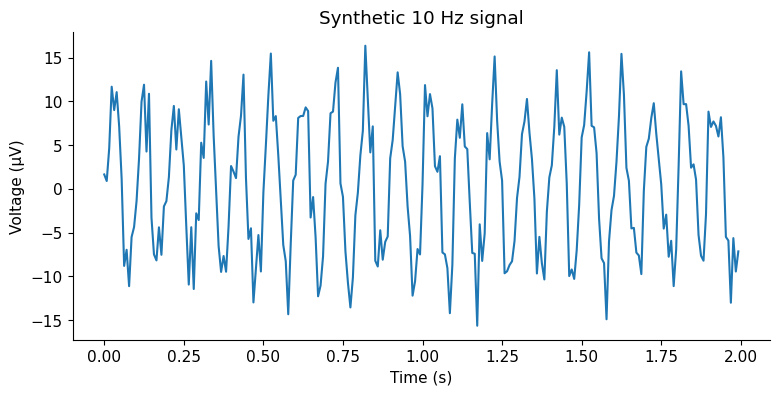

In [12]:
# Create axes; plotting changes the display, not the analyzed data.
fig, ax = plt.subplots()
# Expose the numerical array; EEG values are in volts and the final axis is time.
ax.plot(t[:256], raw.get_data()[1, :256] * 1000000.0)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.set(xlabel='Time (s)', ylabel='Voltage (µV)', title='Synthetic 10 Hz signal')
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Step 1.3 · trace the next operation

**1.** Check a required invariant now so a silent alignment or numerical error cannot propagate.

In [13]:
# Check a required invariant now so a silent alignment or numerical error cannot propagate.
assert raw.get_data().shape == (2, 1280)

### Inspect and interpret

Count approximately ten cycles in one second of the plotted waveform. If the period is unexpected, inspect the sampling metadata and the time vector separately. Noise changes individual peaks, but the intended oscillation period is 0.1 s.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 2 · Change the clock without changing the samples

**Try it:** Make a second Raw object with the same samples but twice the sampling rate. Predict its duration and apparent oscillation frequency.

**My reasoning / hand calculation:** _write here._

In [14]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

The number of stored columns stays fixed; time per column halves.

### Worked solution

Run the following calculation after attempting your own version.

In [15]:
lab_samples=raw.get_data().copy()
lab_fast=mne.io.RawArray(lab_samples,mne.create_info(raw.ch_names,2*sfreq,'eeg'),verbose=False)
print('Original / new duration (s):',raw.n_times/sfreq,lab_fast.n_times/lab_fast.info['sfreq'])
print('Same numerical samples:',np.array_equal(raw.get_data(),lab_fast.get_data()))

Original / new duration (s): 10.0 5.0
Same numerical samples: True


### Interpret and check

The duration halves and the apparent oscillation frequency doubles from 10 to 20 Hz. This is metadata reinterpretation, not resampling. In real work, changing a header to obtain a desired frequency would be incorrect.

## From events to averages
The third event column is a condition code. Baseline subtraction removes each epoch’s pre-event mean; it is not a high-pass filter.

The event code is mapped to a named condition. `Epochs` extracts one segment for each event, and `average` reduces the trial axis. The simulated oscillation is not a physiological ERP; its purpose is to make the data transformations visible.

### Step 2.1 · trace the next operation

**1.** Store this intermediate result so the next operation can be traced and inspected.

**2.** Create event-aligned trials with the stated interval, baseline and quality rules.

**3.** Expose the numerical array; EEG values are in volts and the final axis is time.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Render the completed figure and inspect labels, units and the comparison.

Raw: (2, 1280) Epochs: (4, 2, 104)


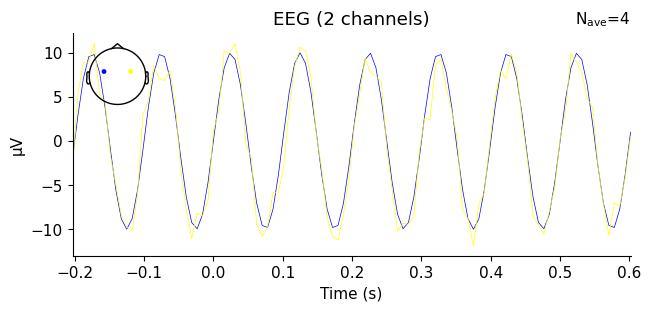

In [16]:
# Store this intermediate result so the next operation can be traced and inspected.
events = np.array([[256, 0, 1], [512, 0, 1], [768, 0, 1], [1024, 0, 1]])
# Create event-aligned trials with the stated interval, baseline and quality rules.
epochs = mne.Epochs(raw, events, {'cue': 1}, -0.2, 0.6, baseline=(-0.2, 0), preload=True)
# Expose the numerical array; EEG values are in volts and the final axis is time.
print('Raw:', raw.get_data().shape, 'Epochs:', epochs.get_data().shape)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
epochs.average().plot(show=False)
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Inspect and interpret

Read `epochs.get_data().shape` as trials, channels and times. Check the first and last values in `epochs.times`. Explain what information is lost when the trials are averaged.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 3 · Trace one epoch back to its source

**Try it:** Find the first epoch’s event sample, relative time zero and number of time samples. Explain why there are more than 0.8 × 128 samples.

**My reasoning / hand calculation:** _write here._

In [17]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

MNE includes the requested endpoint when it lies on the discrete time grid; inspect the actual times.

### Worked solution

Run the following calculation after attempting your own version.

In [18]:
print('First event sample:',epochs.events[0,0])
print('Epoch shape:',epochs.get_data().shape)
print('First and last relative times:',epochs.times[[0,-1]])
print('Nearest zero-time index:',np.argmin(abs(epochs.times)))

First event sample: 256
Epoch shape: (4, 2, 104)
First and last relative times: [-0.203125   0.6015625]
Nearest zero-time index: 26


### Interpret and check

The bounds are rounded to the available sample grid and the last sample is included. The actual time vector, rather than an assumed duration-times-rate product, determines the shape. The event index is in acquisition samples, while the epoch time vector is relative to that event.

## Practice 4 · Explain an axis error before coding

**Try it:** A friend uses X.mean(axis=-1) and calls the result an ERP. Write the output shape and correct the operation.

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

An ERP averages trials, not time.

### Worked solution

For $X$ with shape $N\times C\times T$, `mean(axis=-1)` gives $N\times C$: it discards waveform timing. `mean(axis=0)` gives $C\times T$, the class-specific ERP when X contains trials of one class. Both are legal computations, but they answer different questions.

## Practice 5 · Explain what a copy protects

**Try it:** Why do we write raw.copy().filter(...) when comparing filtered and original signals?

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Many MNE transformations change their object in place.

### Worked solution

A copy gives the transformation its own data object. Without it, the “before” trace may already be filtered, making the comparison misleading. Copying does not create an independent biological recording and must never be used to inflate a sample count.

## Practice 6 · explain the complete method

Without looking back, explain the measurement, transformation, feature or summary, and the evaluation boundary. Include one failure mode and one claim the result does not establish.

**My explanation:** _write here._

### Worked answer · compare your reasoning

One EEG sample is a voltage difference tied to a sensor, time grid and unit. Raw retains a continuous recording; Epochs adds an event-aligned trial axis; Evoked removes that axis by averaging. A defensible analysis checks units, shapes and event meaning before fitting a model.

## If your result is different

If a peak or period is unexpected, compare the time vector with Info["sfreq"]. If a mean has the wrong shape, write the axis names before changing axis=.

If a dataset download fails, read the error and retry when the public host is reachable; do not silently replace real data with simulated values. If a notebook cell refers to an undefined variable, restart the kernel and run the preceding cells in order. Numerical scores can vary slightly with library versions; record versions and compare the protocol before concluding that a method changed.

## Can you now do this independently?

- Explain each arrow in the lesson map and the units at its boundaries.
- Reproduce the hand calculation and point to its corresponding code.
- Interpret the figures without turning a descriptive pattern into an unsupported causal claim.
- Complete a practice task before reading its worked solution.
- State which choices were fixed and which were learned from calibration data.

If one item is unclear, return to the associated figure or practice section before the next lesson.

## Next steps and sources
[MNE data structures](https://mne.tools/stable/auto_tutorials/intro/10_overview.html). Continue to notebook 01.

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.